              precision    recall  f1-score   support

           0       0.77      0.76      0.77       150
           1       0.57      0.58      0.57        81

    accuracy                           0.70       231
   macro avg       0.67      0.67      0.67       231
weighted avg       0.70      0.70      0.70       231



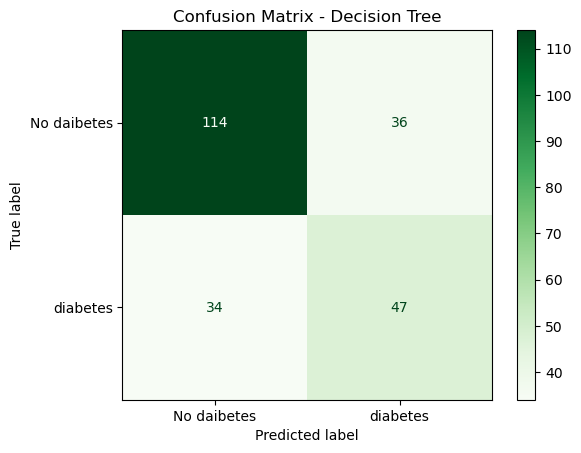

In [28]:
#Decision Tree - Diabetes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree,export_text
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

#------------------------------------------------------------------------------------------
#1.Load and prepare data

df = pd.read_csv("diabetes.csv")

x=df.drop("Outcome",axis=1)
y=df["Outcome"]

#------------------------------------------------------------------------------------------
#2.Train-test split
#------------------------------------------------------------------------------------------
X_train,X_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.3,
    random_state=101
)

#-----------------------------------------------------------------------------------------
#Standardize the data by scaling and encoding

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)

X_test = pd.DataFrame(scaler.transform(X_test),columns=X_test.columns)

#-----------------------------------------------------------------------------------------
#Model Training
#----------------------------------------------------------------------------------------
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train,y_train)

#-------------------------------------------------------------------------------------
#Evaluate model
#---------------------------------------------------------------------------------------

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["No daibetes","diabetes"]).plot(cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")

print(classification_report(y_test,y_pred))


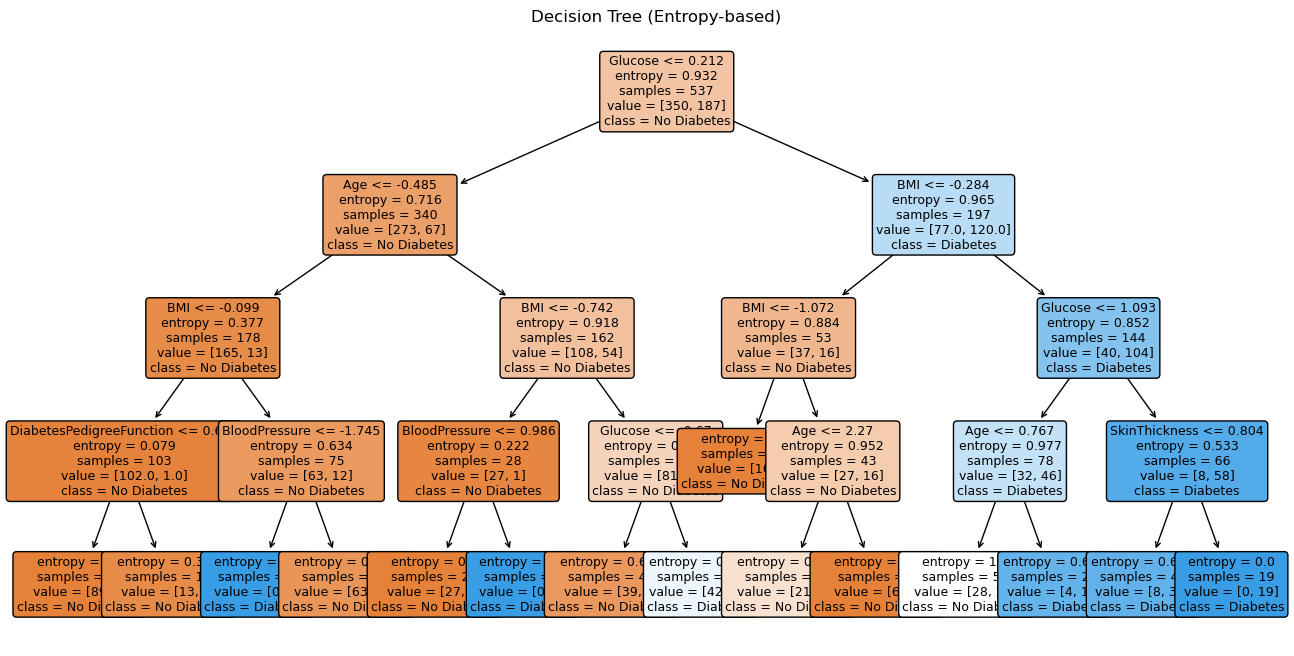

In [15]:
#------------------------------------------------------------------------------------------
# 4. Visualize Decision Tree
#-------------------------------------------------------------------------------------------

plt.figure(figsize=(16,8))
plot_tree(model,feature_names=x.columns,class_names=["No Diabetes","Diabetes"],filled=True,rounded=True,fontsize=9)
plt.title("Decision Tree (Entropy-based)")
plt.show()

Text(0.5, 1.0, 'Confusion Matrix - Decision Tree')

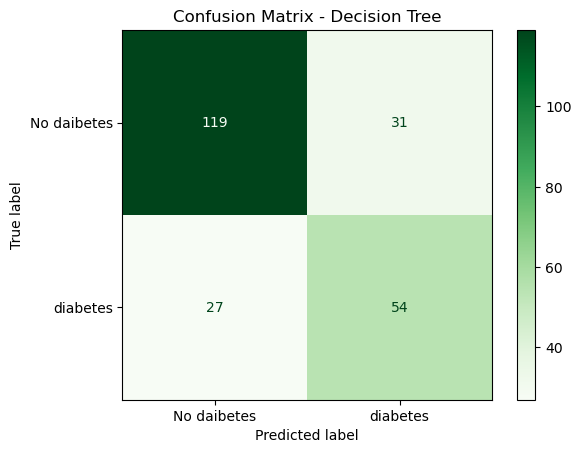

In [16]:
#code without max_depth parameter, we observe that we get the decision tree till the end.
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
model.fit(X_train,y_train)

#-------------------------------------------------------------------------------------
#Evaluate model
#---------------------------------------------------------------------------------------

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["No daibetes","diabetes"]).plot(cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")

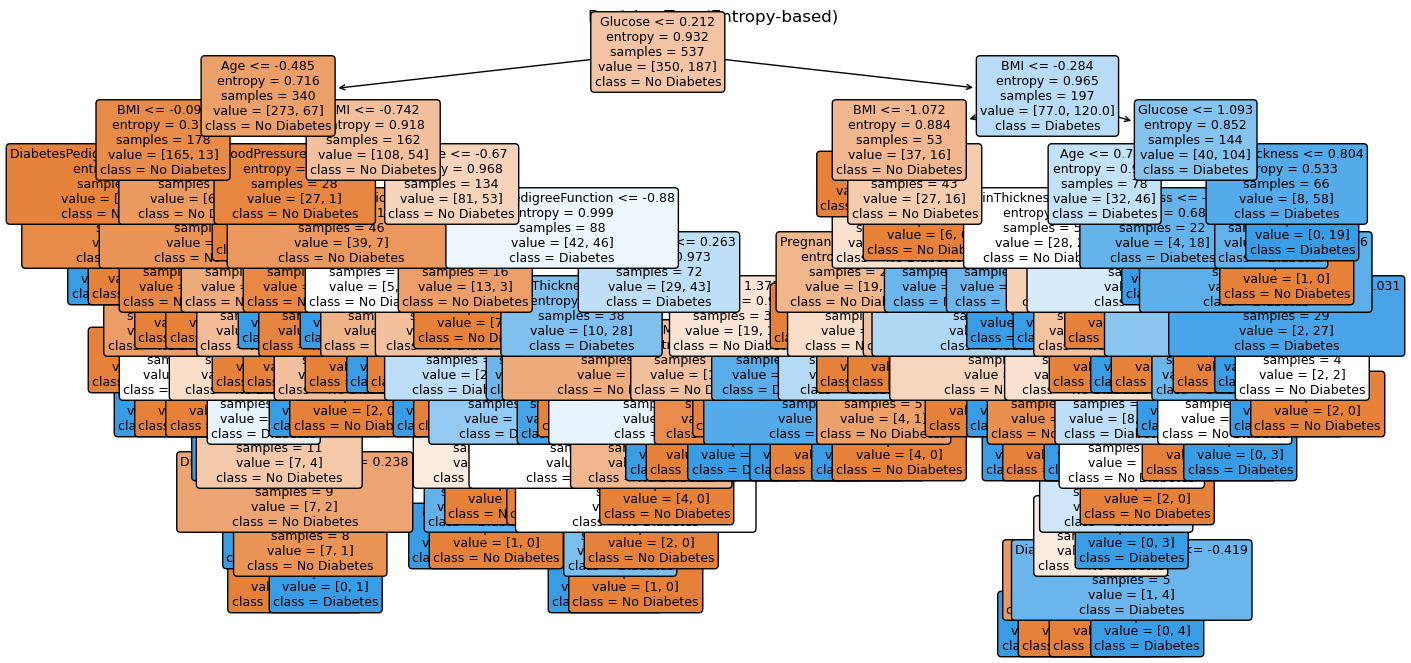

In [17]:
#------------------------------------------------------------------------------------------
# 4. Visualize Decision Tree
#-------------------------------------------------------------------------------------------

plt.figure(figsize=(16,8))
plot_tree(model,feature_names=x.columns,class_names=["No Diabetes","Diabetes"],filled=True,rounded=True,fontsize=9)
plt.title("Decision Tree (Entropy-based)")
plt.show()

In [19]:
#tree importances

tree_rules = export_text(model,feature_names=list(x.columns))
print("\n Decision Tree rules ")
print(tree_rules)


 Decision Tree rules 
|--- Glucose <= 0.21
|   |--- Age <= -0.49
|   |   |--- BMI <= -0.10
|   |   |   |--- DiabetesPedigreeFunction <= 0.62
|   |   |   |   |--- class: 0
|   |   |   |--- DiabetesPedigreeFunction >  0.62
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.67
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- DiabetesPedigreeFunction >  0.67
|   |   |   |   |   |--- class: 0
|   |   |--- BMI >  -0.10
|   |   |   |--- BloodPressure <= -1.74
|   |   |   |   |--- class: 1
|   |   |   |--- BloodPressure >  -1.74
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.07
|   |   |   |   |   |--- BMI <= 0.16
|   |   |   |   |   |   |--- Glucose <= -0.34
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Glucose >  -0.34
|   |   |   |   |   |   |   |--- Insulin <= -0.18
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Insulin >  -0.18
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- BMI >  0.16
|   |   |   


Feature Importance (based on Information Gain:

                    Feature  Importance
1                   Glucose    0.269316
5                       BMI    0.183283
6  DiabetesPedigreeFunction    0.154410
7                       Age    0.124783
2             BloodPressure    0.109012
3             SkinThickness    0.069508
4                   Insulin    0.053885
0               Pregnancies    0.035803


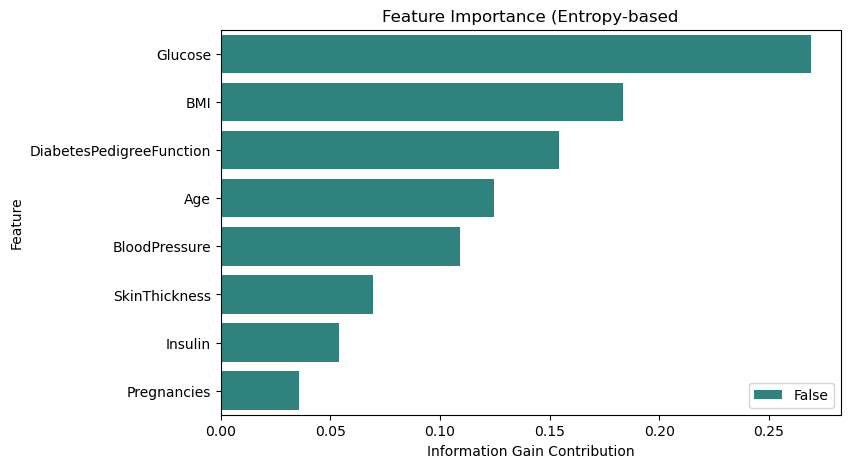

C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


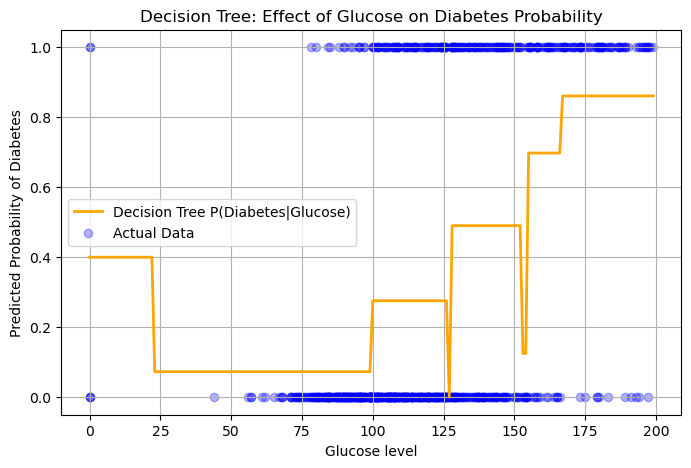

In [27]:
#------------------------------------------------------
#6.Feature Importance (Information Gain)
#------------------------------------------------------
importances = pd.DataFrame({
    "Feature":x.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance",ascending=False)
print("\nFeature Importance (based on Information Gain:\n")
print(importances)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance",y="Feature",data=importances,hue=False,palette="viridis")
plt.title("Feature Importance (Entropy-based")
plt.xlabel("Information Gain Contribution")
plt.ylabel("Feature")
plt.show()

#7.Visualize Glucose vs Diabetes

model_glucose = DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=42)
model_glucose.fit(df[["Glucose"]],y)

glucose_range = np.linspace(df["Glucose"].min(),df["Glucose"].max(),200).reshape(-1,1)
y_curve = model_glucose.predict_proba(glucose_range)[:,1]

plt.figure(figsize=(8,5))
plt.plot(glucose_range,y_curve,color="orange",linewidth = 2, label = "Decision Tree P(Diabetes|Glucose)")
plt.scatter(df["Glucose"],y,color="blue",alpha=0.3,label="Actual Data")
plt.xlabel("Glucose level")
plt.ylabel("Predicted Probability of Diabetes")
plt.title("Decision Tree: Effect of Glucose on Diabetes Probability")
plt.legend()
plt.grid(True)
plt.show()